# Example

<IPython.core.display.Javascript object>


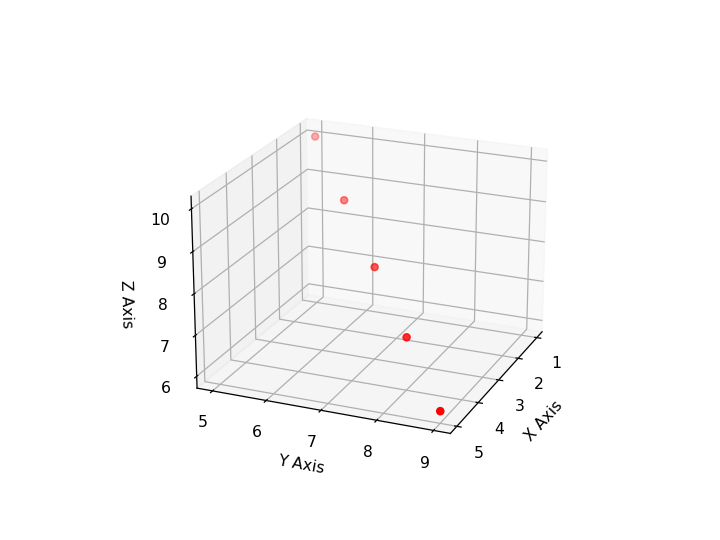

In [34]:

%matplotlib notebook

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = [1, 2, 3, 4, 5]
y = [5, 6, 7, 8, 9]
z = [10, 9, 8, 7, 6]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c='r', marker='o')

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

plt.show()


# Implementation

In [55]:
import json

with open('my_project/controllers/my_controller/learnt_policies.json', 'r') as f:
    data = json.load(f)

all_trajectories = []

for policy in data:
    trajectory = [policy["Coordinates"][0]] +  policy["SetPairs"][1:] +[policy["Coordinates"][1]]
    
    all_trajectories.append(trajectory)
    
print(all_trajectories)

[[[5, 18], [10, 6], [15, 9], [12, 2], [2, 4], [14, 4], [4, 2], [14, 9], [5, 14], [14, 3], [5, 9], [16, 16]]]


In [56]:
from minisom import MiniSom
import pickle
import csv
import numpy as np

with open('my_project/controllers/my_controller/somVisual.p', 'rb') as infile:
    somVisual = pickle.load(infile)

gps_data=[]
with open("my_project/controllers/my_controller/gps_hand.csv", "r", newline='') as gps_csvfile:
    gps_reader = csv.reader(gps_csvfile)
   
    for row in gps_reader:
        gps_data.append([float(value) for value in row[1:]])  # Pasar la columna del indice
                

weights_som = somVisual.get_weights()

def get_coordinate(input):
    som_winner =weights_som[input[0], input[1]]
    return som_winner

#denormalize a vector given dataset
def denormalize_vector(normalized_vector, data):
    # Calculate min and max for each feature in the dataset
    min_values = np.min(data, axis=0)
    max_values = np.max(data, axis=0)
    
    # Denormalize the vector
    denormalized_vector = []
    for i in range(len(normalized_vector)):
        denormalized_value = normalized_vector[i] * (max_values[i] - min_values[i]) + min_values[i]
        denormalized_vector.append(denormalized_value)
    return denormalized_vector

# Reutilizar esta matriz para cada coordenada relativa
def to_global_coordinates(relative_coord, global_position):
    return np.dot(fixed_rotation_matrix, relative_coord) + global_position


global_position=[0,0,0.344]
# Si la rotación es de 90° alrededor del eje Z
yaw = np.pi / 2  # 90 grados en radianes
pitch = 0        # No hay inclinación en el eje Y
roll = 0         # No hay rotación lateral en el eje X
 

# Fijar una matriz de rotación conocida
fixed_rotation_matrix = R.from_euler('xyz', [roll, pitch, yaw]).as_matrix()

all_coordinates= []
for trajectory in all_trajectories:
    new_coordinates=[]
    for coordinate in trajectory:
        new_coord=get_coordinate(coordinate)
        new_coord=list(new_coord)
        new_coord=denormalize_vector(new_coord, gps_data)
        global_coord=to_global_coordinates(new_coord,global_position)
        new_coordinates.append(global_coord) 
    all_coordinates.append(new_coordinates)
    
print(all_coordinates)

[[array([0.15294727, 0.20171626, 0.3596601 ]), array([0.15281608, 0.21705795, 0.47443817]), array([0.19309981, 0.20019512, 0.46179389]), array([0.13372964, 0.20503187, 0.51885005]), array([0.1095195 , 0.23845866, 0.47044771]), array([0.15659853, 0.20026634, 0.51304768]), array([0.10562501, 0.2375208 , 0.49741505]), array([0.1848497 , 0.20354121, 0.45958719]), array([0.14995428, 0.21662622, 0.38927578]), array([0.15249792, 0.19817553, 0.52190006]), array([0.1434256 , 0.23268805, 0.43075548]), array([0.22911855, 0.14918285, 0.31925048])]]


<IPython.core.display.Javascript object>


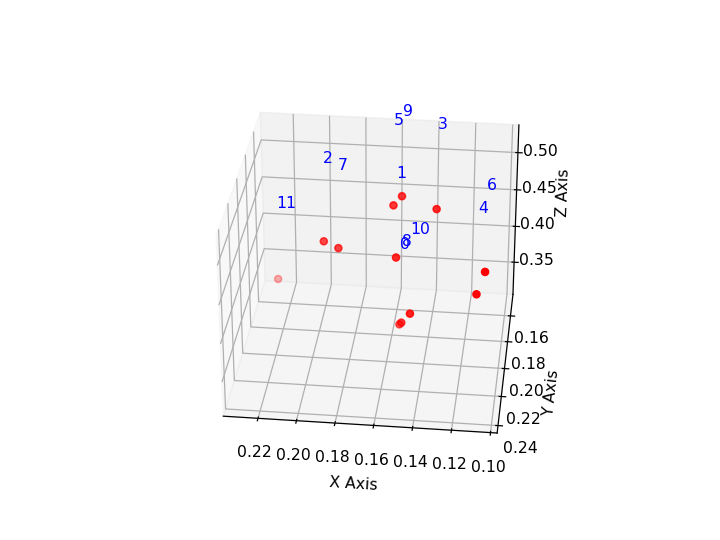

In [57]:
%matplotlib notebook

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

for i in range(len(all_coordinates)):
    trajectory_to_plot= all_coordinates[i]

    x = []
    y = []
    z = []

    for coordinate in trajectory_to_plot:
        x.append(coordinate[0])
        y.append(coordinate[1])
        z.append(coordinate[2])

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(x, y, z, c='r', marker='o')
    
    for index, (x_coord, y_coord, z_coord) in enumerate(trajectory_to_plot):
        ax.text(x_coord, y_coord, z_coord + 0.1, str(index), color='blue')  # Adjust z + 0.1 to position text above the point


    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')

    plt.show()

In [33]:
def evaluate_buffer( buffer):
    # Condition 3: Verify if the buffer is strictly decreasing or non-increasing
    is_decreasing = all(buffer[i] >= buffer[i+1] for i in range(len(buffer)-1))
    
    return is_decreasing

buffer =[
            0.034113726062214675,
            0.03410703830089497,
            0.034101720932810026,
            0.034097486430111436,
            0.0340940911238539,
            0.03409139038819758,
            0.0340892711215697,
            0.034087546216764505,
            0.028529815183484655,
            0.014128474767627621,
            0.012757636554861574
        ]
is_decreasing = evaluate_buffer(buffer)

if is_decreasing:
    print(f"Buffer is decreasing")
else:
    print("Buffer is not decreasing.")

Buffer is decreasing


In [54]:

import numpy as np
from scipy.spatial.transform import Rotation as R

# Si la rotación es de 90° alrededor del eje Z
yaw = np.pi / 2  # 90 grados en radianes
pitch = 0        # No hay inclinación en el eje Y
roll = 0         # No hay rotación lateral en el eje X
 

# Fijar una matriz de rotación conocida
fixed_rotation_matrix = R.from_euler('xyz', [roll, pitch, yaw]).as_matrix()

# Reutilizar esta matriz para cada coordenada relativa
def to_global_coordinates(relative_coord, global_position):
    return np.dot(fixed_rotation_matrix, relative_coord) + global_position

# Ejemplo
relative_coord = np.array([1, 0, 0])
global_position = np.array([5, 5, 5])
print("Coordenada global:", to_global_coordinates(relative_coord, global_position))


Coordenada global: [5. 6. 5.]
